# **📉 Customer Churn Prediction using Machine Learning**

Thulasi Baddipudi

Tools: Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn

# 📌 Problem Statement

Customer churn significantly impacts business revenue and growth. This project aims to predict customer churn using machine learning and identify key factors influencing customer retention.

# 📂 Dataset Description
The dataset consists of customer demographic details, service usage, billing information, and churn status. The target variable is Churn (Yes/No).



# 📑 Project Workflow
1. Data Understanding

2. Data Cleaning & Preprocessing

3. Exploratory Data Analysis (EDA)

4. Model Building

5. Model Evaluation

6. Insights & Interpretation

7. Feature Engineering

8. Business Insights

9. Conclusion


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the dataset
import pandas as pd
from sklearn.datasets import fetch_openml

# Fetch dataset from OpenML
churn = fetch_openml(name="Telco-Customer-Churn", version=1, as_frame=True)

df = churn.frame

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,'No phone service',DSL,No,Yes,No,No,No,No,Month-to-month,Yes,'Electronic check',29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,'One year',No,'Mailed check',56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,'Mailed check',53.85,108.15,Yes
3,Male,0,No,No,45,No,'No phone service',DSL,Yes,No,Yes,Yes,No,No,'One year',No,'Bank transfer (automatic)',42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,'Fiber optic',No,No,No,No,No,No,Month-to-month,Yes,'Electronic check',70.70,151.65,Yes


In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#---------------------------------------------------------------------------------------------------------------------------------

In [6]:
# Check missing values
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [7]:
df.dropna(inplace=True)

In [ ]:
#--------------------------------------------------------------------------------------------------------------------

In [8]:
# Encode categorical variables
label_encoder = LabelEncoder()

for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

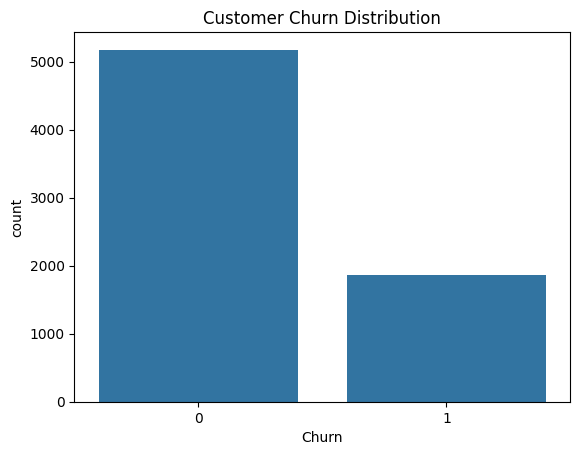

In [9]:
#Exploratory Data Analysis (EDA)
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------

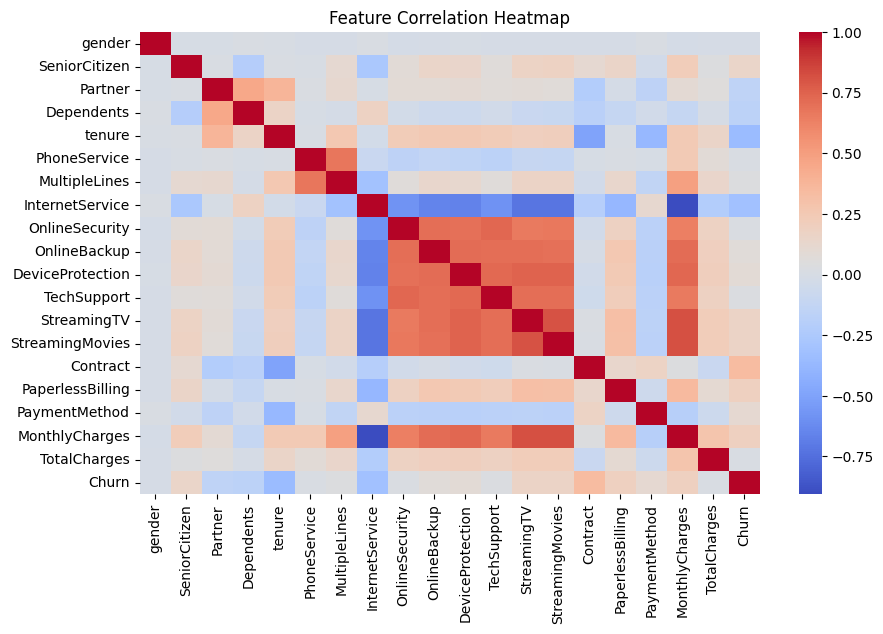

In [10]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#----------------------------------------------------------------------------------------------------------------------------------------

In [14]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert categorical columns into numeric using get_dummies
X = pd.get_dummies(X, drop_first=True)

X.shape

(7043, 19)

In [15]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#----------------------------------------------------------------------------------------------------------------------------

In [16]:
#Model Building – Logistic Regressio
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------

In [17]:
#Model Prediction
y_pred = model.predict(X_test)

In [18]:
#Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8161816891412349


In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------------

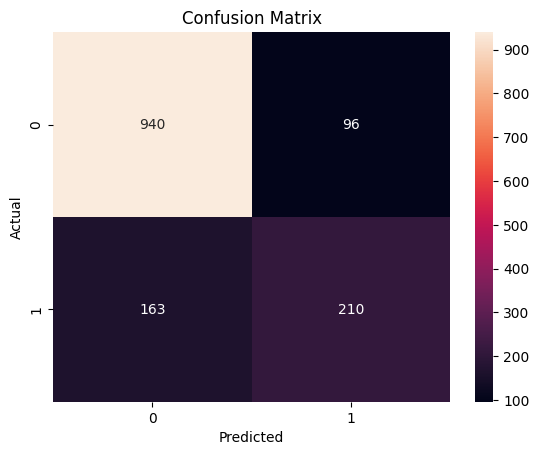

In [19]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------

In [20]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



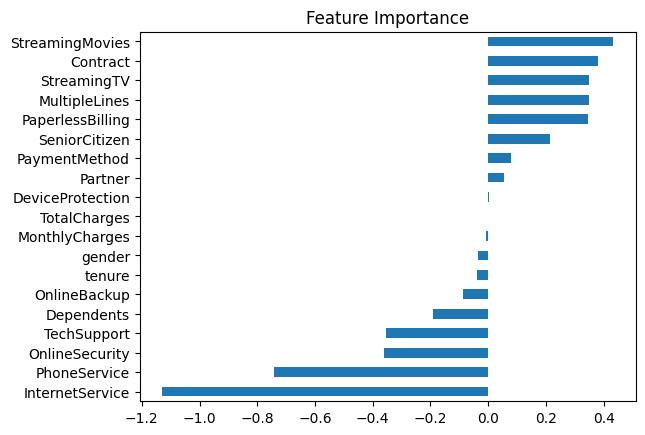

In [21]:
#Feature Importance
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

  ##   Business Insights

From the model results we can derive several insights:

Certain features strongly influence customer churn.

Customers with specific service patterns may be more likely to leave.

Businesses can target these customers with retention strategies such as:

personalized offers

better customer support

loyalty programs

# 🔮 Future Improvements
Apply advanced ensemble models

Perform hyperparameter tuning

Deploy the model using a web framework

Automate data pipelines






# ✅ Conclusion

In this project, we built a machine learning model to predict customer churn using Logistic Regression.

Key achievements of this project include:

Data preprocessing and cleaning

Exploratory Data Analysis

Feature selection

Model training and evaluation

Identification of important churn factors

The model can help telecom companies identify customers who are likely to churn and take proactive measures to retain them, ultimately improving customer satisfaction and business revenue.